Starting data processing pipeline...
[Step 1] Found 23 files. (Time elapsed: 0.0115 sec)
[Step 2] Dataset combined via open_mfdataset. (Time elapsed: 0.9303 sec)
[Step 3] Computational graph generated. (Time elapsed: 0.0136 sec)
[Step 4] Executing computations (This may take a while)...
[Step 4] Data computation finished. (Time elapsed: 10.20 sec)
[Step 5] Plot rendering finished. (Time elapsed: 0.0643 sec)
--------------------------------------------------
Total pipeline execution time: 11.22 seconds (0.19 minutes)


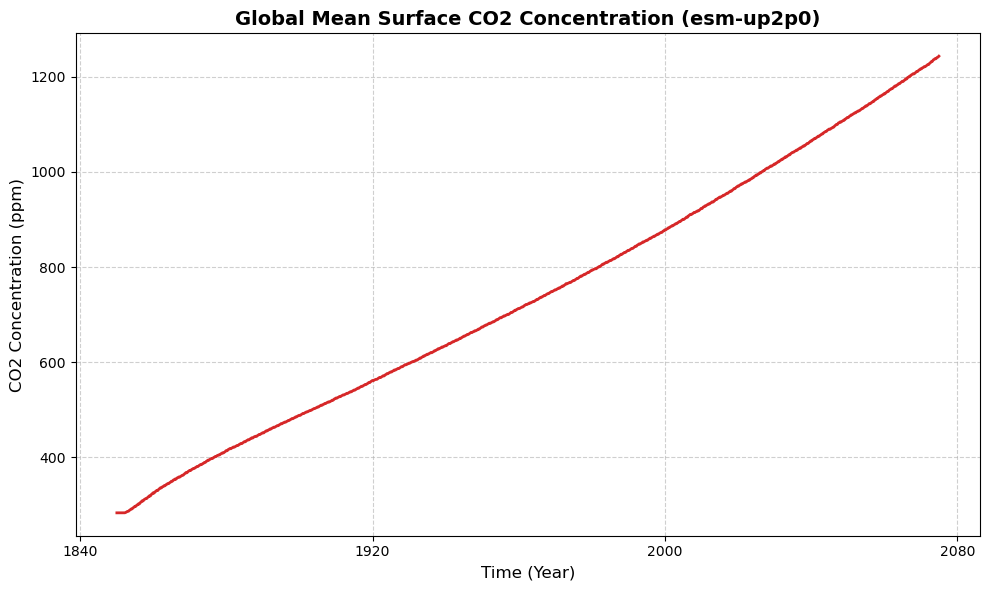

In [1]:
import xarray as xr
import numpy as np
import matplotlib.pyplot as plt
import glob
import time
import warnings

# Ignore xarray's DeprecationWarning to keep the output clean
warnings.filterwarnings("ignore", category=DeprecationWarning)

# --- Start Total Timer ---
total_start_time = time.time()
print("Starting data processing pipeline...")

# 1. File Search
step_start = time.time()
file_pattern = "/nird/datalake/NS2980K/projects/TipESM/cmor/esm-up2p0/v20251010/co2_Amon_NorESM2-LM_esm-up2p0_r1i1p1f1_gn_*.nc"
files = sorted(glob.glob(file_pattern))
step_end = time.time()
print(f"[Step 1] Found {len(files)} files. (Time elapsed: {step_end - step_start:.4f} sec)")

# 2. Open Dataset (Lazy Load)
step_start = time.time()
# Reverted to the older syntax, but the warning is now suppressed by the warnings module
ds = xr.open_mfdataset(
    files, 
    combine='by_coords', 
    use_cftime=True, 
    data_vars='minimal'
)
step_end = time.time()
print(f"[Step 2] Dataset combined via open_mfdataset. (Time elapsed: {step_end - step_start:.4f} sec)")

# 3. Setup Computational Graph (Surface extraction, weights, global mean)
step_start = time.time()
co2_sfc = ds['co2'].isel(plev=-1)
weights = np.cos(np.deg2rad(ds.lat))
co2_sfc_weighted = co2_sfc.weighted(weights)
co2_global_mean = co2_sfc_weighted.mean(dim=['lat', 'lon'])
co2_ppm = co2_global_mean * 1e6
step_end = time.time()
print(f"[Step 3] Computational graph generated. (Time elapsed: {step_end - step_start:.4f} sec)")

# 4. Execute Computation (Loading data into memory)
# This step will take the longest as it actually processes the NetCDF files.
step_start = time.time()
print("[Step 4] Executing computations (This may take a while)...")
co2_ppm_computed = co2_ppm.compute() 
step_end = time.time()
print(f"[Step 4] Data computation finished. (Time elapsed: {step_end - step_start:.2f} sec)")

# 5. Visualization
step_start = time.time()
plt.figure(figsize=(10, 6))
co2_ppm_computed.plot(color='#d62728', linewidth=2) 

plt.title('Global Mean Surface CO2 Concentration (esm-up2p0)', fontsize=14, fontweight='bold')
plt.xlabel('Time (Year)', fontsize=12)
plt.ylabel('CO2 Concentration (ppm)', fontsize=12)
plt.grid(True, linestyle='--', alpha=0.6)
plt.tight_layout()
step_end = time.time()
print(f"[Step 5] Plot rendering finished. (Time elapsed: {step_end - step_start:.4f} sec)")

# --- End Total Timer ---
total_end_time = time.time()
total_elapsed = total_end_time - total_start_time
print("-" * 50)
print(f"Total pipeline execution time: {total_elapsed:.2f} seconds ({total_elapsed/60:.2f} minutes)")

# plt.savefig('global_mean_surface_co2_timeseries.png', dpi=300)
plt.show()

Starting ocean data processing pipeline...
[Step 1] Found 23 files. (Time elapsed: 0.0115 sec)
[Step 2] Dataset combined via open_mfdataset. (Time elapsed: 2.1834 sec)
[Step 3] Computational graph generated. (Time elapsed: 0.0134 sec)
[Step 4] Executing computations (This may take a while for 3D ocean data)...
[Step 4] Data computation finished. (Time elapsed: 174.20 sec)
[Step 5] Plot rendering finished. (Time elapsed: 0.0628 sec)
--------------------------------------------------
Total pipeline execution time: 176.47 seconds (2.94 minutes)


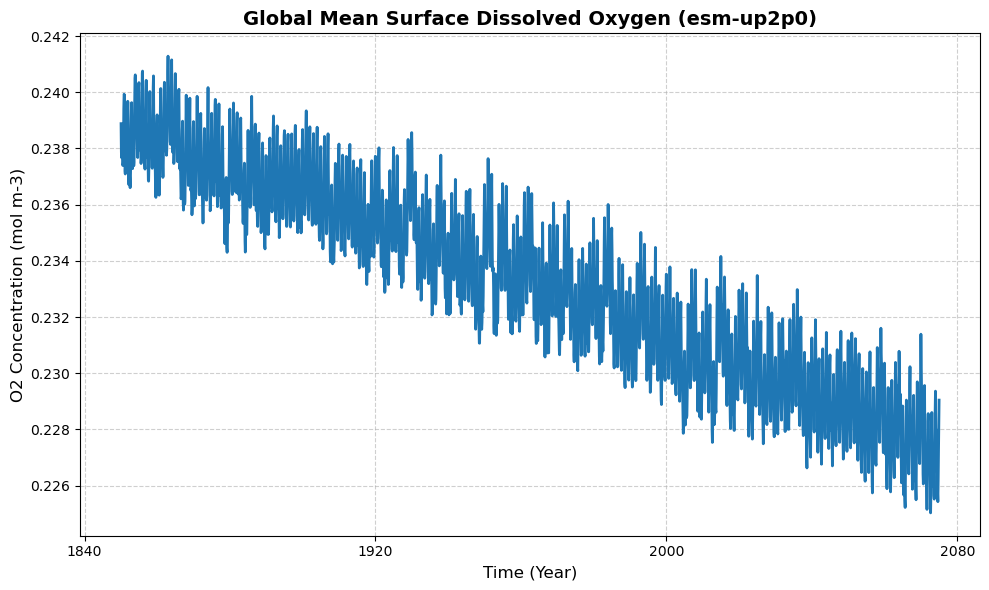

In [2]:
import xarray as xr
import numpy as np
import matplotlib.pyplot as plt
import glob
import time
import warnings

# Ignore xarray's DeprecationWarning to keep the terminal clean
warnings.filterwarnings("ignore", category=DeprecationWarning)

# --- Start Total Timer ---
total_start_time = time.time()
print("Starting ocean data processing pipeline...")

# 1. File Search
step_start = time.time()
# Assuming the o2 files are in the same general directory structure as before
file_pattern = "/nird/datalake/NS2980K/projects/TipESM/cmor/esm-up2p0/v20251010/o2_Omon_NorESM2-LM_esm-up2p0_r1i1p1f1_gr_*.nc"
files = sorted(glob.glob(file_pattern))
step_end = time.time()
print(f"[Step 1] Found {len(files)} files. (Time elapsed: {step_end - step_start:.4f} sec)")

# 2. Open Dataset (Lazy Load)
step_start = time.time()
ds = xr.open_mfdataset(
    files, 
    combine='by_coords', 
    use_cftime=True, 
    data_vars='minimal',
    coords='minimal',
    compat='override'
)
step_end = time.time()
print(f"[Step 2] Dataset combined via open_mfdataset. (Time elapsed: {step_end - step_start:.4f} sec)")

# 3. Setup Computational Graph (Surface extraction, weights, global mean)
step_start = time.time()
# Ocean surface is the first vertical level (index 0) because lev:positive = "down"
o2_sfc = ds['o2'].isel(lev=0)

# Ocean data uses 2D coordinates for unstructured grids (latitude, longitude)
# We use the 'latitude' variable to calculate the area weights
weights = np.cos(np.deg2rad(ds['latitude']))
o2_sfc_weighted = o2_sfc.weighted(weights)

# Calculate the mean over the spatial dimensions 'j' and 'i'
o2_global_mean = o2_sfc_weighted.mean(dim=['j', 'i'])
step_end = time.time()
print(f"[Step 3] Computational graph generated. (Time elapsed: {step_end - step_start:.4f} sec)")

# 4. Execute Computation (Loading data into memory)
step_start = time.time()
print("[Step 4] Executing computations (This may take a while for 3D ocean data)...")
o2_global_mean_computed = o2_global_mean.compute() 
step_end = time.time()
print(f"[Step 4] Data computation finished. (Time elapsed: {step_end - step_start:.2f} sec)")

# 5. Visualization
step_start = time.time()
plt.figure(figsize=(10, 6))
# Using a nice ocean blue color for O2
o2_global_mean_computed.plot(color='#1f77b4', linewidth=2) 

plt.title('Global Mean Surface Dissolved Oxygen (esm-up2p0)', fontsize=14, fontweight='bold')
plt.xlabel('Time (Year)', fontsize=12)
plt.ylabel('O2 Concentration (mol m-3)', fontsize=12)
plt.grid(True, linestyle='--', alpha=0.6)
plt.tight_layout()
step_end = time.time()
print(f"[Step 5] Plot rendering finished. (Time elapsed: {step_end - step_start:.4f} sec)")

# --- End Total Timer ---
total_end_time = time.time()
total_elapsed = total_end_time - total_start_time
print("-" * 50)
print(f"Total pipeline execution time: {total_elapsed:.2f} seconds ({total_elapsed/60:.2f} minutes)")

# plt.savefig('global_mean_surface_o2_timeseries.png', dpi=300)
plt.show()

Starting ocean o2sat data processing pipeline...
[Step 1] Found 23 files. (Time elapsed: 0.0114 sec)
[Step 2] Dataset combined via open_mfdataset. (Time elapsed: 2.2246 sec)
[Step 3] Computational graph generated. (Time elapsed: 0.0161 sec)
[Step 4] Executing computations (This may take a while)...
[Step 4] Data computation finished. (Time elapsed: 165.73 sec)
[Step 5] Plot rendering finished. (Time elapsed: 0.1668 sec)
--------------------------------------------------
Total pipeline execution time: 168.15 seconds (2.80 minutes)


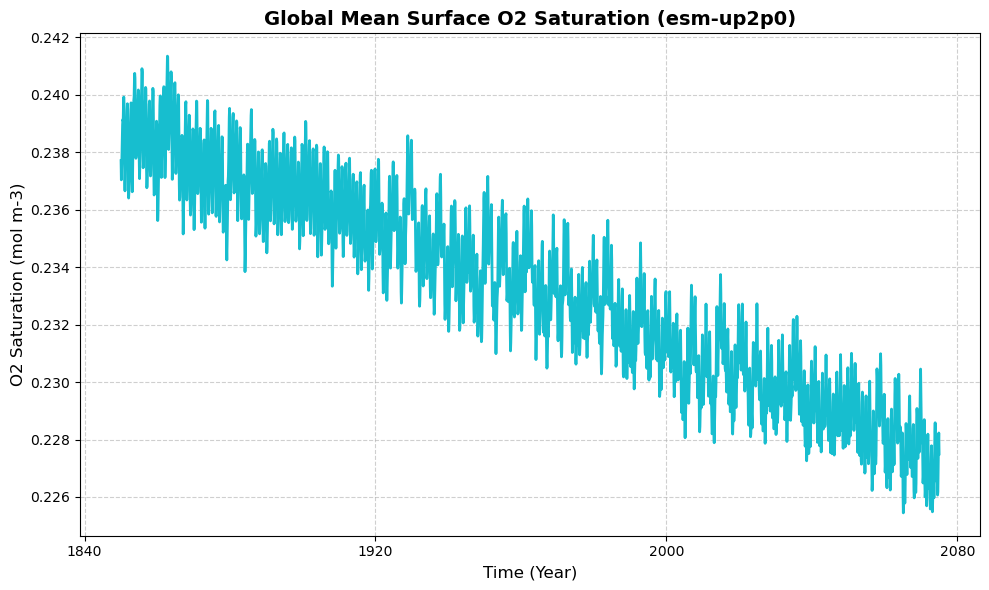

In [3]:
import xarray as xr
import numpy as np
import matplotlib.pyplot as plt
import glob
import time
import warnings

# Ignore xarray's DeprecationWarning to keep the terminal clean
warnings.filterwarnings("ignore", category=DeprecationWarning)

# --- Start Total Timer ---
total_start_time = time.time()
print("Starting ocean o2sat data processing pipeline...")

# 1. File Search
step_start = time.time()
file_pattern = "/nird/datalake/NS2980K/projects/TipESM/cmor/esm-up2p0/v20251010/o2sat_Omon_NorESM2-LM_esm-up2p0_r1i1p1f1_gr_*.nc"
files = sorted(glob.glob(file_pattern))
step_end = time.time()
print(f"[Step 1] Found {len(files)} files. (Time elapsed: {step_end - step_start:.4f} sec)")

# 2. Open Dataset (Lazy Load)
step_start = time.time()
ds = xr.open_mfdataset(
    files, 
    combine='by_coords', 
    use_cftime=True, 
    data_vars='minimal',
    coords='minimal',
    compat='override'
)
step_end = time.time()
print(f"[Step 2] Dataset combined via open_mfdataset. (Time elapsed: {step_end - step_start:.4f} sec)")

# 3. Setup Computational Graph (Surface extraction, weights, global mean)
step_start = time.time()
# Extract the surface layer (index 0)
o2sat_sfc = ds['o2sat'].isel(lev=0)

# Calculate area weights using the 2D 'latitude' array
weights = np.cos(np.deg2rad(ds['latitude']))
o2sat_sfc_weighted = o2sat_sfc.weighted(weights)

# Calculate the mean over the spatial dimensions 'j' and 'i'
o2sat_global_mean = o2sat_sfc_weighted.mean(dim=['j', 'i'])
step_end = time.time()
print(f"[Step 3] Computational graph generated. (Time elapsed: {step_end - step_start:.4f} sec)")

# 4. Execute Computation (Loading data into memory)
step_start = time.time()
print("[Step 4] Executing computations (This may take a while)...")
o2sat_global_mean_computed = o2sat_global_mean.compute() 
step_end = time.time()
print(f"[Step 4] Data computation finished. (Time elapsed: {step_end - step_start:.2f} sec)")

# 5. Visualization
step_start = time.time()
plt.figure(figsize=(10, 6))
# Using a slightly different color (e.g., a cyan/teal) to distinguish from standard o2
o2sat_global_mean_computed.plot(color='#17becf', linewidth=2) 

plt.title('Global Mean Surface O2 Saturation (esm-up2p0)', fontsize=14, fontweight='bold')
plt.xlabel('Time (Year)', fontsize=12)
plt.ylabel('O2 Saturation (mol m-3)', fontsize=12)
plt.grid(True, linestyle='--', alpha=0.6)
plt.tight_layout()
step_end = time.time()
print(f"[Step 5] Plot rendering finished. (Time elapsed: {step_end - step_start:.4f} sec)")

# --- End Total Timer ---
total_end_time = time.time()
total_elapsed = total_end_time - total_start_time
print("-" * 50)
print(f"Total pipeline execution time: {total_elapsed:.2f} seconds ({total_elapsed/60:.2f} minutes)")

# plt.savefig('global_mean_surface_o2sat_timeseries.png', dpi=300)
plt.show()

Starting ocean zo2min data processing pipeline...
[Step 1] Found 23 files. (Time elapsed: 0.0118 sec)
[Step 2] Dataset combined via open_mfdataset. (Time elapsed: 0.8916 sec)
[Step 3] Computational graph generated. (Time elapsed: 0.0186 sec)
[Step 4] Executing computations (This should be faster than 3D fields)...
[Step 4] Data computation finished. (Time elapsed: 4.18 sec)
[Step 5] Plot rendering finished. (Time elapsed: 0.0577 sec)
--------------------------------------------------
Total pipeline execution time: 5.16 seconds (0.09 minutes)


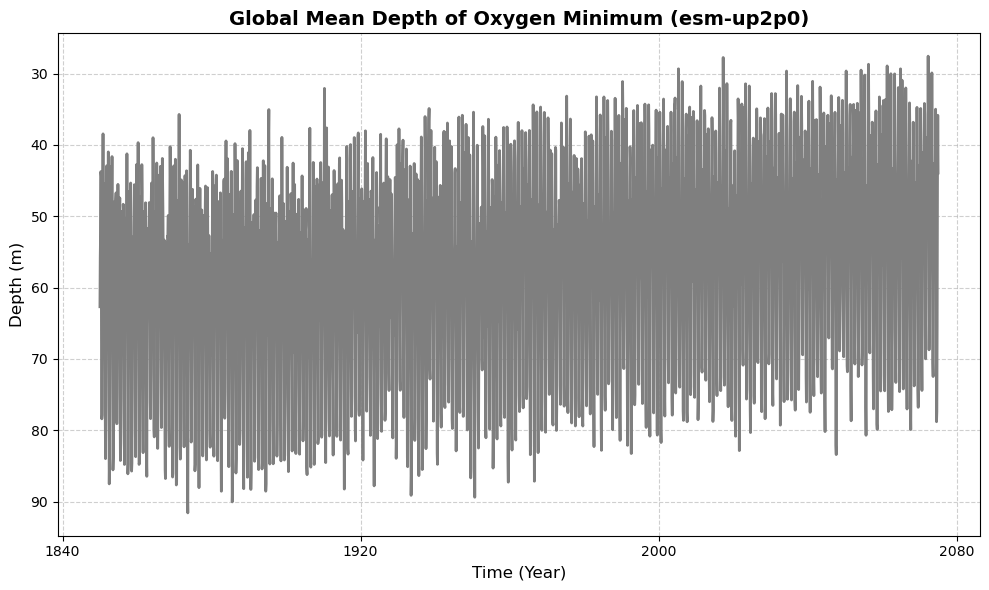

In [6]:
import xarray as xr
import numpy as np
import matplotlib.pyplot as plt
import glob
import time
import warnings

# Ignore xarray's DeprecationWarning to keep the terminal clean
warnings.filterwarnings("ignore", category=DeprecationWarning)

# --- Start Total Timer ---
total_start_time = time.time()
print("Starting ocean zo2min data processing pipeline...")

# 1. File Search
step_start = time.time()
file_pattern = "/nird/datalake/NS2980K/projects/TipESM/cmor/esm-up2p0/v20251010/zo2min_Omon_NorESM2-LM_esm-up2p0_r1i1p1f1_gr_*.nc"
files = sorted(glob.glob(file_pattern))
step_end = time.time()
print(f"[Step 1] Found {len(files)} files. (Time elapsed: {step_end - step_start:.4f} sec)")

# 2. Open Dataset (Lazy Load)
step_start = time.time()
ds = xr.open_mfdataset(
    files, 
    combine='by_coords', 
    use_cftime=True, 
    data_vars='minimal',
    coords='minimal',
    compat='override'
)
step_end = time.time()
print(f"[Step 2] Dataset combined via open_mfdataset. (Time elapsed: {step_end - step_start:.4f} sec)")

# 3. Setup Computational Graph (Weights, global mean)
step_start = time.time()
# zo2min is already a 2D horizontal variable over time (time, j, i), so NO vertical slicing is needed.
zo2min_data = ds['zo2min']

# Calculate area weights using the 2D 'latitude' array
weights = np.cos(np.deg2rad(ds['latitude']))
zo2min_weighted = zo2min_data.weighted(weights)

# Calculate the mean over the spatial dimensions 'j' and 'i'
zo2min_global_mean = zo2min_weighted.mean(dim=['j', 'i'])
step_end = time.time()
print(f"[Step 3] Computational graph generated. (Time elapsed: {step_end - step_start:.4f} sec)")

# 4. Execute Computation (Loading data into memory)
step_start = time.time()
print("[Step 4] Executing computations (This should be faster than 3D fields)...")
zo2min_global_mean_computed = zo2min_global_mean.compute() 
step_end = time.time()
print(f"[Step 4] Data computation finished. (Time elapsed: {step_end - step_start:.2f} sec)")

# 5. Visualization
step_start = time.time()
plt.figure(figsize=(10, 6))
zo2min_global_mean_computed.plot(color='#7f7f7f', linewidth=2) 

plt.title('Global Mean Depth of Oxygen Minimum (esm-up2p0)', fontsize=14, fontweight='bold')
plt.xlabel('Time (Year)', fontsize=12)
plt.ylabel('Depth (m)', fontsize=12)
plt.grid(True, linestyle='--', alpha=0.6)

# Invert y-axis so that deeper depths are displayed downwards
plt.gca().invert_yaxis() 
plt.tight_layout()
step_end = time.time()
print(f"[Step 5] Plot rendering finished. (Time elapsed: {step_end - step_start:.4f} sec)")

# --- End Total Timer ---
total_end_time = time.time()
total_elapsed = total_end_time - total_start_time
print("-" * 50)
print(f"Total pipeline execution time: {total_elapsed:.2f} seconds ({total_elapsed/60:.2f} minutes)")

# plt.savefig('global_mean_zo2min_timeseries.png', dpi=300)
plt.show()

In [8]:
import xarray as xr
import numpy as np
import time
import warnings

# Suppress deprecation warnings to keep output clean
warnings.filterwarnings("ignore", category=DeprecationWarning)

# --- Start Total Timer ---
total_start_time = time.time()
print("Starting MLD Oxygen Inventory test pipeline...")

# 1. Define file paths for a single 10-year period (185001-185912)
step_start = time.time()
o2_file = "/nird/datalake/NS2980K/projects/TipESM/cmor/esm-up2p0/v20251010/o2_Omon_NorESM2-LM_esm-up2p0_r1i1p1f1_gr_185001-185912.nc"
mld_file = "/nird/datalake/NS2980K/projects/TipESM/cmor/esm-up2p0/v20251010/mlotst_Omon_NorESM2-LM_esm-up2p0_r1i1p1f1_gn_185001-185912.nc"

ds_o2 = xr.open_dataset(o2_file, use_cftime=True)
ds_mld = xr.open_dataset(mld_file, use_cftime=True)
step_end = time.time()
print(f"[Step 1] Files loaded into xarray. (Time elapsed: {step_end - step_start:.4f} sec)")

# 2. Grid Alignment (Interpolate MLD from 'gn' to 'gr' grid)
step_start = time.time()
mld_native = ds_mld['mlotst']
o2_spatial_target = ds_o2['o2'].isel(time=0, lev=0)

print("[Step 2] Aligning grids: Interpolating mlotst (gn) to o2 grid (gr)...")
# Regrid MLD to match O2 spatial dimensions (j, i)
mld_aligned = mld_native.interp_like(o2_spatial_target, method='linear')
step_end = time.time()
print(f"[Step 2] Grid alignment finished. (Time elapsed: {step_end - step_start:.2f} sec)")

# 3. Calculate Vertical Layer Thickness and Overlap with MLD
step_start = time.time()
# Extract depth bounds for each ocean layer (dimension: lev)
z_top = ds_o2['lev_bnds'].isel(bnds=0)
z_bot = ds_o2['lev_bnds'].isel(bnds=1)

# Vectorized intersection: find how many meters of each layer lie ABOVE the MLD
# Use numpy's minimum which perfectly supports xarray DataArrays
overlap = np.minimum(z_bot, mld_aligned) - z_top
overlap = xr.where(overlap > 0, overlap, 0)

# Multiply 3D O2 (mol m-3) by the overlap thickness (m) and sum along the vertical axis 'lev'
# Resulting inventory unit: mol m-2
o2_inventory = (ds_o2['o2'] * overlap).sum(dim='lev')
step_end = time.time()
print(f"[Step 3] Computational graph for MLD integration constructed. (Time elapsed: {step_end - step_start:.4f} sec)")

# 4. Trigger Computation via Global Area-Weighted Mean
step_start = time.time()
print("[Step 4] Executing calculation by computing global mean timeseries...")
weights = np.cos(np.deg2rad(ds_o2['latitude']))
o2_inv_global = o2_inventory.weighted(weights).mean(dim=['j', 'i'])

# Actual computing happens here
o2_inv_computed = o2_inv_global.compute()
step_end = time.time()
print(f"[Step 4] Data computation finished. (Time elapsed: {step_end - step_start:.2f} sec)")

# --- End Total Timer ---
total_end_time = time.time()
print("-" * 50)
print(f"Total test execution time: {total_end_time - total_start_time:.2f} seconds")

Starting MLD Oxygen Inventory test pipeline...
[Step 1] Files loaded into xarray. (Time elapsed: 0.0235 sec)
[Step 2] Aligning grids: Interpolating mlotst (gn) to o2 grid (gr)...
[Step 2] Grid alignment finished. (Time elapsed: 0.54 sec)
[Step 3] Computational graph for MLD integration constructed. (Time elapsed: 27.9393 sec)
[Step 4] Executing calculation by computing global mean timeseries...
[Step 4] Data computation finished. (Time elapsed: 0.07 sec)
--------------------------------------------------
Total test execution time: 28.57 seconds


In [12]:
import xarray as xr
import numpy as np
import time
import os
import warnings

# Ignore deprecation warnings to keep the terminal output clean
warnings.filterwarnings("ignore", category=DeprecationWarning)

# --- Start Total Timer ---
total_start_time = time.time()
print("Starting Multi-Depth O2 Inventory generation pipeline...")

# 1. Define Input and Output Paths
step_start = time.time()
o2_file = "/nird/datalake/NS2980K/projects/TipESM/cmor/esm-up2p0/v20251010/o2_Omon_NorESM2-LM_esm-up2p0_r1i1p1f1_gr_185001-185912.nc"
mld_file = "/nird/datalake/NS2980K/projects/TipESM/cmor/esm-up2p0/v20251010/mlotst_Omon_NorESM2-LM_esm-up2p0_r1i1p1f1_gn_185001-185912.nc"

output_dir = "/nird/datalake/NS2980K/users/yongyub/O2_linearlity/TipESM/cmor/esm-up2p0/v20251010"
# Changed file name to reflect multi-inventory contents
output_file = "o2-inventories_Omon_NorESM2-LM_esm-up2p0_r1i1p1f1_gr_185001-185912.nc"
output_path = os.path.join(output_dir, output_file)

ds_o2 = xr.open_dataset(o2_file, use_cftime=True)
ds_mld = xr.open_dataset(mld_file, use_cftime=True)
step_end = time.time()
print(f"[Step 1] Input files successfully loaded. (Time elapsed: {step_end - step_start:.4f} sec)")

# 2. Grid Alignment (Interpolate MLD to O2 grid)
step_start = time.time()
mld_aligned = ds_mld['mlotst'].interp_like(ds_o2['o2'].isel(time=0, lev=0), method='linear')
step_end = time.time()
print(f"[Step 2] Grid alignment for MLD finished. (Time elapsed: {step_end - step_start:.2f} sec)")

# 3. Setup Integration Variables
step_start = time.time()
z_top = ds_o2['lev_bnds'].isel(bnds=0)
z_bot = ds_o2['lev_bnds'].isel(bnds=1)
o2_data = ds_o2['o2']

# Dictionary to hold our computed variables before packaging into a Dataset
data_vars_dict = {
    'mlotst': (['time', 'j', 'i'], mld_aligned.data, {
        'long_name': 'Ocean Mixed Layer Thickness (Interpolated to gr grid)',
        'units': 'm'
    })
}

# --- A. Mixed Layer Depth (MLD) Inventory ---
overlap_mld = np.minimum(z_bot, mld_aligned) - z_top
overlap_mld = xr.where(overlap_mld > 0, overlap_mld, 0)
o2_inv_mld = (o2_data * overlap_mld).sum(dim='lev')
data_vars_dict['o2_inv_mld'] = (['time', 'j', 'i'], o2_inv_mld.data, {
    'long_name': 'O2 Inventory above Mixed Layer Depth', 'units': 'mol m-2'
})

# --- B. Fixed Depth Inventories ---
target_depths = [100, 200, 300, 500, 700, 1000, 1500, 2000]

for depth in target_depths:
    # Subgrid logic works perfectly with scalar depths
    overlap_fixed = np.minimum(z_bot, depth) - z_top
    overlap_fixed = xr.where(overlap_fixed > 0, overlap_fixed, 0)
    o2_inv_fixed = (o2_data * overlap_fixed).sum(dim='lev')
    
    var_name = f'o2_inv_{depth}m'
    data_vars_dict[var_name] = (['time', 'j', 'i'], o2_inv_fixed.data, {
        'long_name': f'O2 Inventory from surface to {depth}m', 'units': 'mol m-2'
    })

# --- C. Total Water Column Inventory ---
# Total thickness of each cell is simply z_bot - z_top
overlap_total = z_bot - z_top
overlap_total = xr.where(overlap_total > 0, overlap_total, 0)
o2_inv_total = (o2_data * overlap_total).sum(dim='lev')
data_vars_dict['o2_inv_total'] = (['time', 'j', 'i'], o2_inv_total.data, {
    'long_name': 'Total Water Column O2 Inventory', 'units': 'mol m-2'
})

step_end = time.time()
print(f"[Step 3] Computational graphs for all {len(target_depths) + 2} inventories constructed. (Time elapsed: {step_end - step_start:.4f} sec)")

# 4. Construct Multi-Variable Dataset
step_start = time.time()
out_ds = xr.Dataset(
    data_vars=data_vars_dict,
    coords={
        'time': ds_o2['time'],
        'latitude': ds_o2['latitude'],
        'longitude': ds_o2['longitude']
    }
)
step_end = time.time()
print(f"[Step 4] Dataset packaging finished. (Time elapsed: {step_end - step_start:.4f} sec)")

# 5. Export to NetCDF File
step_start = time.time()
os.makedirs(output_dir, exist_ok=True)
print(f"[Step 5] Computing and writing all variables to NetCDF (This will take time)...")
# The actual heavy lifting happens here. xarray computes all layers and depths simultaneously.
out_ds.to_netcdf(output_path)
step_end = time.time()
print(f"[Step 5] NetCDF file saved successfully. (Time elapsed: {step_end - step_start:.2f} sec)")

# --- End Total Timer ---
total_end_time = time.time()
print("-" * 50)
print(f"Total multi-depth execution time: {total_end_time - total_start_time:.2f} seconds")

Starting Multi-Depth O2 Inventory generation pipeline...
[Step 1] Input files successfully loaded. (Time elapsed: 0.0209 sec)
[Step 2] Grid alignment for MLD finished. (Time elapsed: 0.53 sec)
[Step 3] Computational graphs for all 10 inventories constructed. (Time elapsed: 233.2651 sec)
[Step 4] Dataset packaging finished. (Time elapsed: 0.0056 sec)
[Step 5] Computing and writing all variables to NetCDF (This will take time)...
[Step 5] NetCDF file saved successfully. (Time elapsed: 0.51 sec)
--------------------------------------------------
Total multi-depth execution time: 234.34 seconds


In [13]:
import xarray as xr
import numpy as np
import time
import os
import glob
import warnings

# Ignore deprecation warnings to keep the terminal output clean
warnings.filterwarnings("ignore", category=DeprecationWarning)

# --- Start Total Timer ---
total_start_time = time.time()
print("Starting Production Pipeline: Multi-Depth O2 Inventory for All Periods...")

# 1. Directories and Base Patterns
input_dir = "/nird/datalake/NS2980K/projects/TipESM/cmor/esm-up2p0/v20251010"
output_dir = "/nird/datalake/NS2980K/users/yongyub/O2_linearlity/TipESM/cmor/esm-up2p0/v20251010"
os.makedirs(output_dir, exist_ok=True)

# Find all o2 monthly files
o2_file_pattern = os.path.join(input_dir, "o2_Omon_NorESM2-LM_esm-up2p0_r1i1p1f1_gr_*.nc")
o2_files = sorted(glob.glob(o2_file_pattern))

total_files = len(o2_files)
print(f"Found {total_files} 'o2' files to process.\n")
print("=" * 70)

# Target depths for fixed-depth inventories
target_depths = [100, 200, 300, 500, 700, 1000, 1500, 2000]

# 2. Main Processing Loop
for idx, o2_file in enumerate(o2_files, 1):
    loop_start_time = time.time()
    
    # Extract the time suffix (e.g., '185001-185912.nc') from the o2 filename
    filename = os.path.basename(o2_file)
    time_suffix = filename.split('_')[-1]
    
    # Construct the matching mld filename and output filename
    mld_filename = f"mlotst_Omon_NorESM2-LM_esm-up2p0_r1i1p1f1_gn_{time_suffix}"
    mld_file = os.path.join(input_dir, mld_filename)
    
    output_filename = f"o2-inventories_Omon_NorESM2-LM_esm-up2p0_r1i1p1f1_gr_{time_suffix}"
    output_path = os.path.join(output_dir, output_filename)
    
    print(f"[{idx}/{total_files}] Processing period: {time_suffix.replace('.nc', '')}")
    
    # Check if the matching MLD file exists
    if not os.path.exists(mld_file):
        print(f"  -> WARNING: Matching MLD file not found. Skipping this period.")
        continue
        
    # Check if output already exists to avoid redundant computation (optional)
    if os.path.exists(output_path):
        print(f"  -> Output already exists. Skipping.")
        continue

    # --- Load Data ---
    ds_o2 = xr.open_dataset(o2_file, use_cftime=True)
    ds_mld = xr.open_dataset(mld_file, use_cftime=True)
    
    # --- Align Grids ---
    mld_aligned = ds_mld['mlotst'].interp_like(ds_o2['o2'].isel(time=0, lev=0), method='linear')
    
    # --- Setup Integration Variables ---
    z_top = ds_o2['lev_bnds'].isel(bnds=0)
    z_bot = ds_o2['lev_bnds'].isel(bnds=1)
    o2_data = ds_o2['o2']
    
    data_vars_dict = {
        'mlotst': (['time', 'j', 'i'], mld_aligned.data, {
            'long_name': 'Ocean Mixed Layer Thickness (Interpolated to gr grid)',
            'units': 'm'
        })
    }
    
    # A. Mixed Layer Depth (MLD) Inventory
    overlap_mld = np.minimum(z_bot, mld_aligned) - z_top
    overlap_mld = xr.where(overlap_mld > 0, overlap_mld, 0)
    o2_inv_mld = (o2_data * overlap_mld).sum(dim='lev')
    data_vars_dict['o2_inv_mld'] = (['time', 'j', 'i'], o2_inv_mld.data, {
        'long_name': 'O2 Inventory above Mixed Layer Depth', 'units': 'mol m-2'
    })
    
    # B. Fixed Depth Inventories
    for depth in target_depths:
        overlap_fixed = np.minimum(z_bot, depth) - z_top
        overlap_fixed = xr.where(overlap_fixed > 0, overlap_fixed, 0)
        o2_inv_fixed = (o2_data * overlap_fixed).sum(dim='lev')
        
        var_name = f'o2_inv_{depth}m'
        data_vars_dict[var_name] = (['time', 'j', 'i'], o2_inv_fixed.data, {
            'long_name': f'O2 Inventory from surface to {depth}m', 'units': 'mol m-2'
        })
        
    # C. Total Water Column Inventory
    overlap_total = z_bot - z_top
    overlap_total = xr.where(overlap_total > 0, overlap_total, 0)
    o2_inv_total = (o2_data * overlap_total).sum(dim='lev')
    data_vars_dict['o2_inv_total'] = (['time', 'j', 'i'], o2_inv_total.data, {
        'long_name': 'Total Water Column O2 Inventory', 'units': 'mol m-2'
    })
    
    # --- Save to NetCDF ---
    out_ds = xr.Dataset(
        data_vars=data_vars_dict,
        coords={
            'time': ds_o2['time'],
            'latitude': ds_o2['latitude'],
            'longitude': ds_o2['longitude']
        }
    )
    
    # Write to disk
    out_ds.to_netcdf(output_path)
    
    # --- Clean up Memory (Crucial for loops) ---
    out_ds.close()
    ds_o2.close()
    ds_mld.close()
    
    loop_end_time = time.time()
    print(f"  -> Saved {output_filename} (Took {loop_end_time - loop_start_time:.2f} sec)")

# --- End Total Timer ---
print("=" * 70)
total_end_time = time.time()
print(f"All processing complete! Total elapsed time: {(total_end_time - total_start_time) / 60:.2f} minutes")

Starting Production Pipeline: Multi-Depth O2 Inventory for All Periods...
Found 23 'o2' files to process.

[1/23] Processing period: 185001-185912
  -> Output already exists. Skipping.
[2/23] Processing period: 186001-186912
  -> Saved o2-inventories_Omon_NorESM2-LM_esm-up2p0_r1i1p1f1_gr_186001-186912.nc (Took 234.22 sec)
[3/23] Processing period: 187001-187912
  -> Saved o2-inventories_Omon_NorESM2-LM_esm-up2p0_r1i1p1f1_gr_187001-187912.nc (Took 233.29 sec)
[4/23] Processing period: 188001-188912
  -> Saved o2-inventories_Omon_NorESM2-LM_esm-up2p0_r1i1p1f1_gr_188001-188912.nc (Took 233.40 sec)
[5/23] Processing period: 189001-189912
  -> Saved o2-inventories_Omon_NorESM2-LM_esm-up2p0_r1i1p1f1_gr_189001-189912.nc (Took 233.67 sec)
[6/23] Processing period: 190001-190912
  -> Saved o2-inventories_Omon_NorESM2-LM_esm-up2p0_r1i1p1f1_gr_190001-190912.nc (Took 234.84 sec)
[7/23] Processing period: 191001-191912
  -> Saved o2-inventories_Omon_NorESM2-LM_esm-up2p0_r1i1p1f1_gr_191001-191912.nc

Starting Individual Panel Time Series Visualization Pipeline...
[Step 1] Found 23 inventory files. Loading via open_mfdataset...
  -> Files loaded. (Time elapsed: 0.78 sec)
[Step 2] Weights and variables setup finished. (Time elapsed: 0.00 sec)
[Step 3] Computing global weighted monthly means (This may take a moment)...
  -> Successfully computed monthly and yearly means for: o2_inv_mld
  -> Successfully computed monthly and yearly means for: o2_inv_100m
  -> Successfully computed monthly and yearly means for: o2_inv_200m
  -> Successfully computed monthly and yearly means for: o2_inv_300m
  -> Successfully computed monthly and yearly means for: o2_inv_500m
  -> Successfully computed monthly and yearly means for: o2_inv_700m
  -> Successfully computed monthly and yearly means for: o2_inv_1000m
  -> Successfully computed monthly and yearly means for: o2_inv_1500m
  -> Successfully computed monthly and yearly means for: o2_inv_2000m
  -> Successfully computed monthly and yearly means for

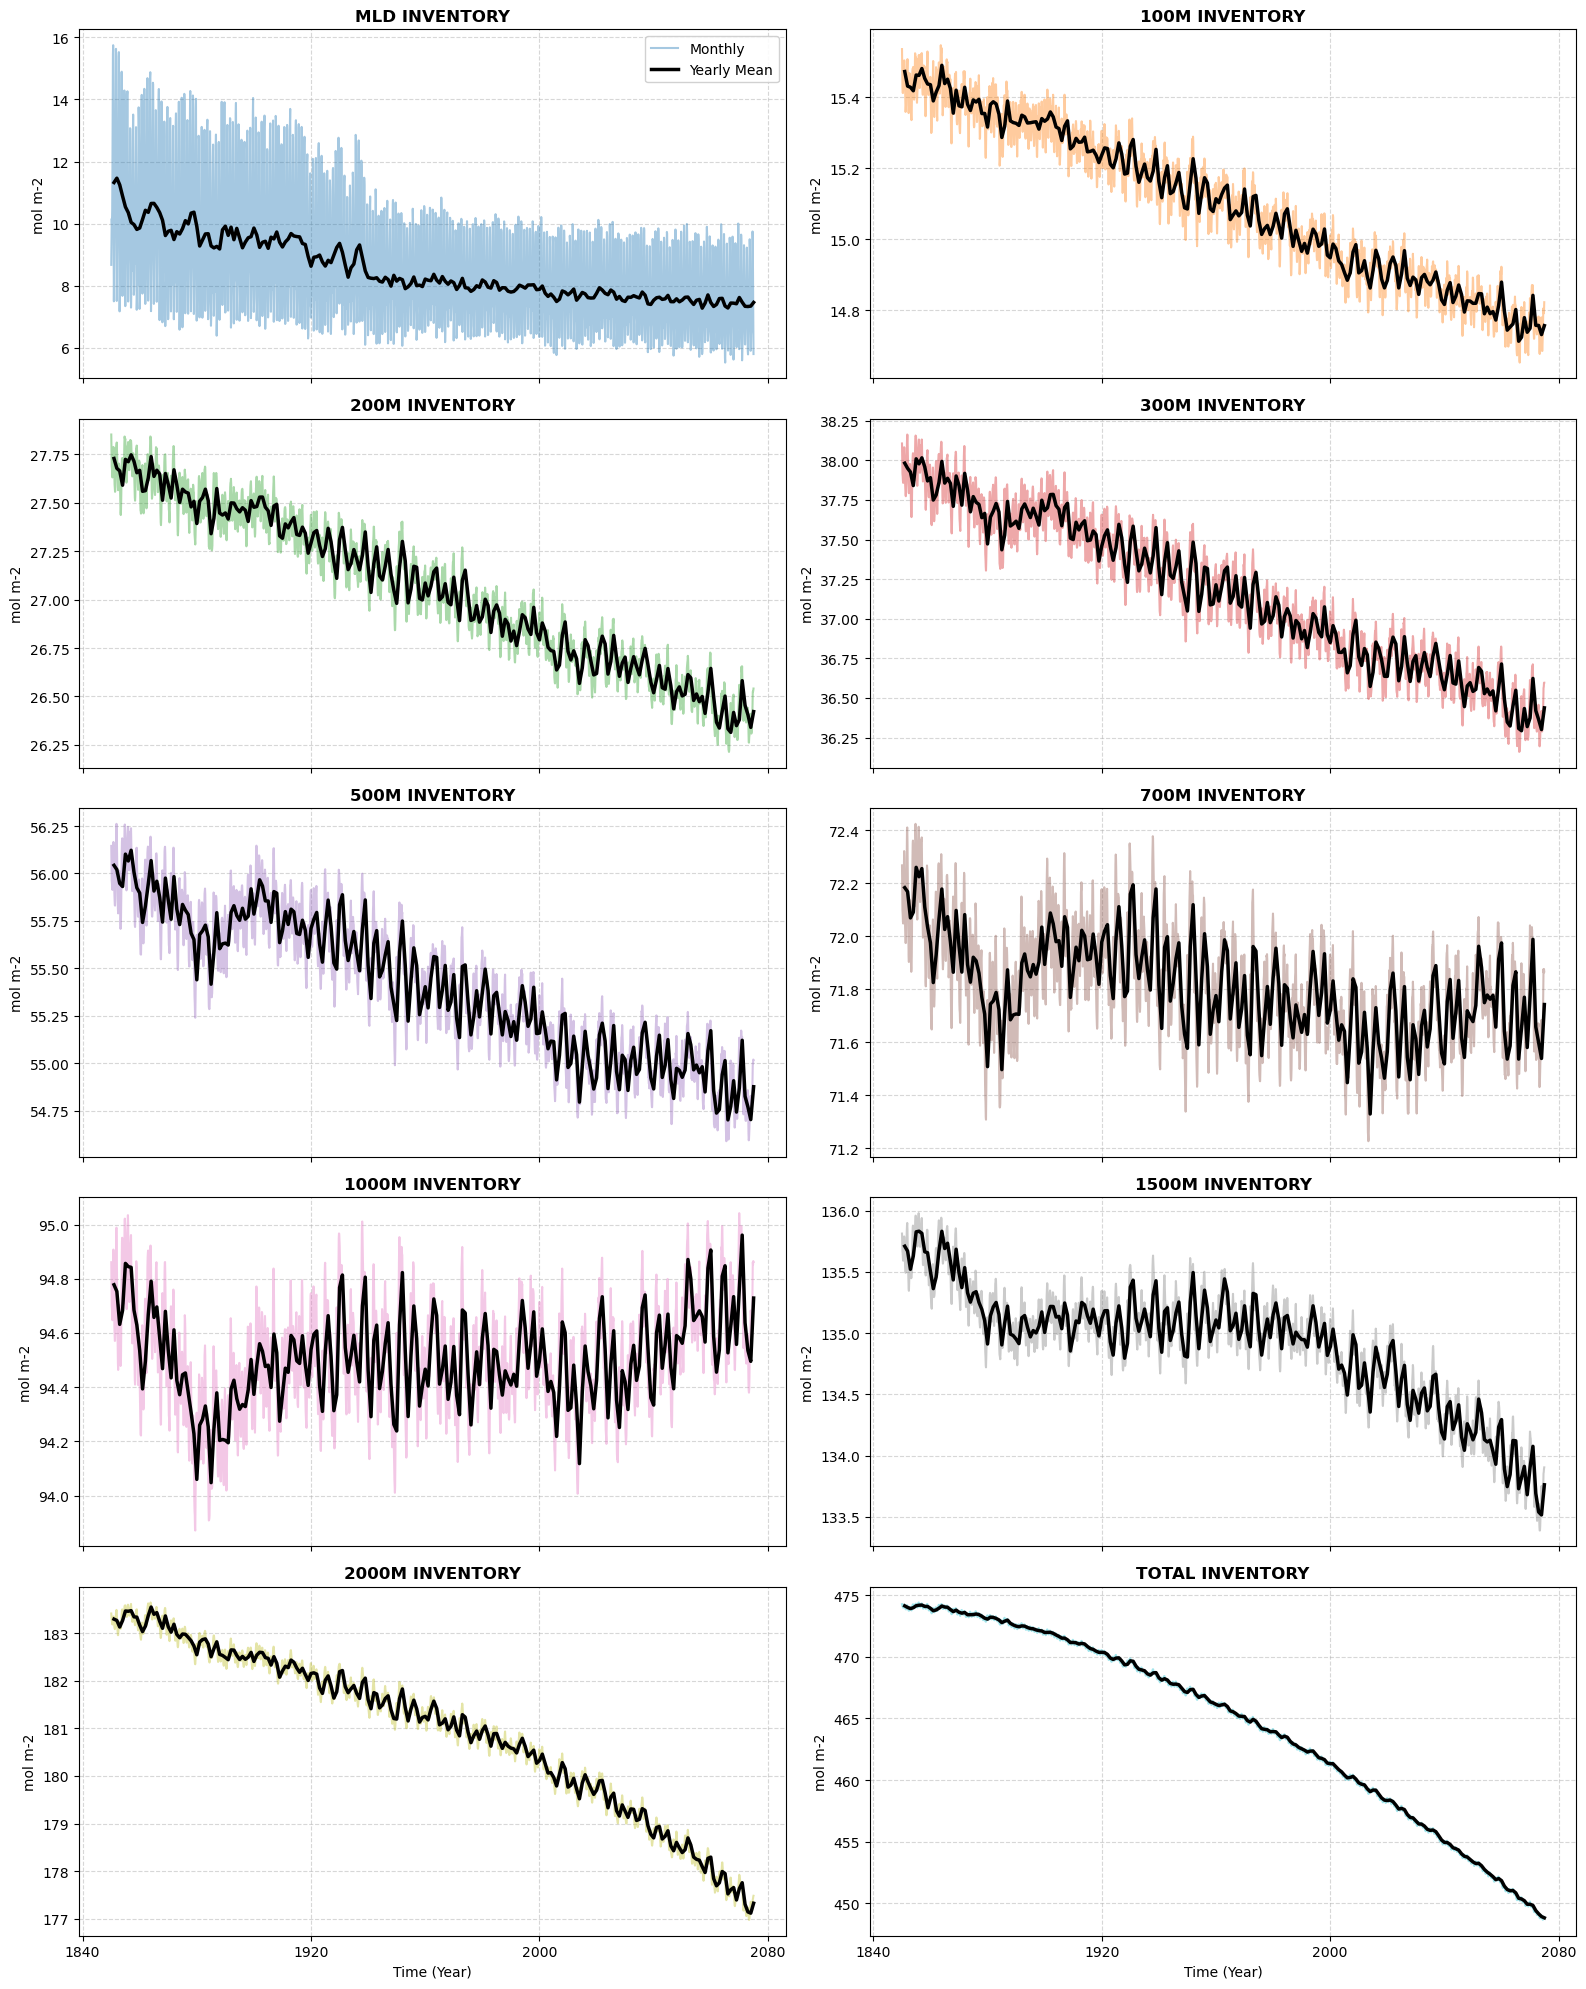

In [16]:
import xarray as xr
import numpy as np
import matplotlib.pyplot as plt
import glob
import time
import warnings

# Ignore deprecation warnings to keep the terminal output clean
warnings.filterwarnings("ignore", category=DeprecationWarning)

# --- Start Total Timer ---
total_start_time = time.time()
print("Starting Individual Panel Time Series Visualization Pipeline...")

# 1. Load the Generated Inventory Data
step_start = time.time()
data_dir = "/nird/datalake/NS2980K/users/yongyub/O2_linearlity/TipESM/cmor/esm-up2p0/v20251010"
file_pattern = f"{data_dir}/o2-inventories_Omon_NorESM2-LM_esm-up2p0_r1i1p1f1_gr_*.nc"
files = sorted(glob.glob(file_pattern))

print(f"[Step 1] Found {len(files)} inventory files. Loading via open_mfdataset...")
ds = xr.open_mfdataset(files, combine='by_coords', use_cftime=True)
step_end = time.time()
print(f"  -> Files loaded. (Time elapsed: {step_end - step_start:.2f} sec)")

# 2. Setup Variables and Area Weights
step_start = time.time()
weights = np.cos(np.deg2rad(ds['latitude']))

# List of all 10 variables we generated
all_vars = [
    'o2_inv_mld', 'o2_inv_100m', 'o2_inv_200m', 'o2_inv_300m', 'o2_inv_500m', 
    'o2_inv_700m', 'o2_inv_1000m', 'o2_inv_1500m', 'o2_inv_2000m', 'o2_inv_total'
]
step_end = time.time()
print(f"[Step 2] Weights and variables setup finished. (Time elapsed: {step_end - step_start:.2f} sec)")

# 3. Compute Global Weighted Means
step_start = time.time()
print("[Step 3] Computing global weighted monthly means (This may take a moment)...")
computed_monthly_data = {}
computed_yearly_data = {}

for var in all_vars:
    if var in ds.variables:
        # Calculate Global Mean
        da_weighted = ds[var].weighted(weights)
        da_mean = da_weighted.mean(dim=['j', 'i'])
        
        # 1. Compute Monthly Data
        computed_monthly_data[var] = da_mean.compute() 
        
        # 2. Compute Yearly Mean Data (Resampling by Year)
        # 'Y' stands for Year end frequency. This perfectly handles cftime calendars.
        computed_yearly_data[var] = da_mean.resample(time='Y').mean().compute()
        
        print(f"  -> Successfully computed monthly and yearly means for: {var}")
        
step_end = time.time()
print(f"[Step 3] Data computation finished. (Time elapsed: {step_end - step_start:.2f} sec)")

# 4. Visualization (5x2 Grid Layout with Yearly Overlays)
step_start = time.time()
print("[Step 4] Rendering individual plots with yearly overlays...")

# Create a 5x2 grid of subplots. sharex=True aligns the time axis for all.
fig, axes = plt.subplots(5, 2, figsize=(16, 20), sharex=True)
axes = axes.flatten() 

# Colormap for distinct monthly plots
colors = plt.cm.tab10.colors

for idx, var in enumerate(all_vars):
    ax = axes[idx]
    if var in computed_monthly_data:
        title_name = var.replace('o2_inv_', '').upper() + ' INVENTORY'
        
        # Plot 1: The original Monthly timeseries 
        # (Made slightly transparent and thinner to act as background noise)
        computed_monthly_data[var].plot(
            ax=ax, 
            color=colors[idx % len(colors)], 
            linewidth=1.5, 
            alpha=0.4, 
            label='Monthly'
        )
        
        # Plot 2: The Yearly Mean overlay
        # (Solid black and thicker to highlight the trend)
        computed_yearly_data[var].plot(
            ax=ax, 
            color='black', 
            linewidth=2.5, 
            label='Yearly Mean'
        )
        
        # Customize each panel
        ax.set_title(title_name, fontsize=12, fontweight='bold')
        ax.set_ylabel('mol m-2', fontsize=10)
        ax.set_xlabel('Time (Year)' if idx >= 8 else '') 
        ax.grid(True, linestyle='--', alpha=0.5)
        
        # Add a legend to the first plot only to keep the grid clean
        if idx == 0:
            ax.legend(loc='upper right', framealpha=0.9)

# Adjust spacing to prevent overlapping titles and labels
plt.tight_layout()

step_end = time.time()
print(f"[Step 4] Plotting finished. (Time elapsed: {step_end - step_start:.2f} sec)")

# --- End Total Timer ---
total_end_time = time.time()
print("-" * 50)
print(f"Total visualization execution time: {total_end_time - total_start_time:.2f} seconds")

# plt.savefig('global_mean_o2_inventories_yearly_overlay.png', dpi=300, bbox_inches='tight')
plt.show()

Starting 3-Panel Sea Ice Concentration Visualization Pipeline...
[Step 1] Found 23 siconc files. Loading via open_mfdataset...
  -> Files loaded. (Time elapsed: 0.43 sec)
[Step 2] Weights (Global, NH, SH) created. (Time elapsed: 0.01 sec)
[Step 3] Computing Global, NH, and SH means (This may take a moment)...
[Step 3] Data computation finished. (Time elapsed: 25.34 sec)
[Step 4] Rendering plots...
[Step 4] Plotting finished. (Time elapsed: 0.18 sec)
--------------------------------------------------
Total visualization execution time: 25.96 seconds


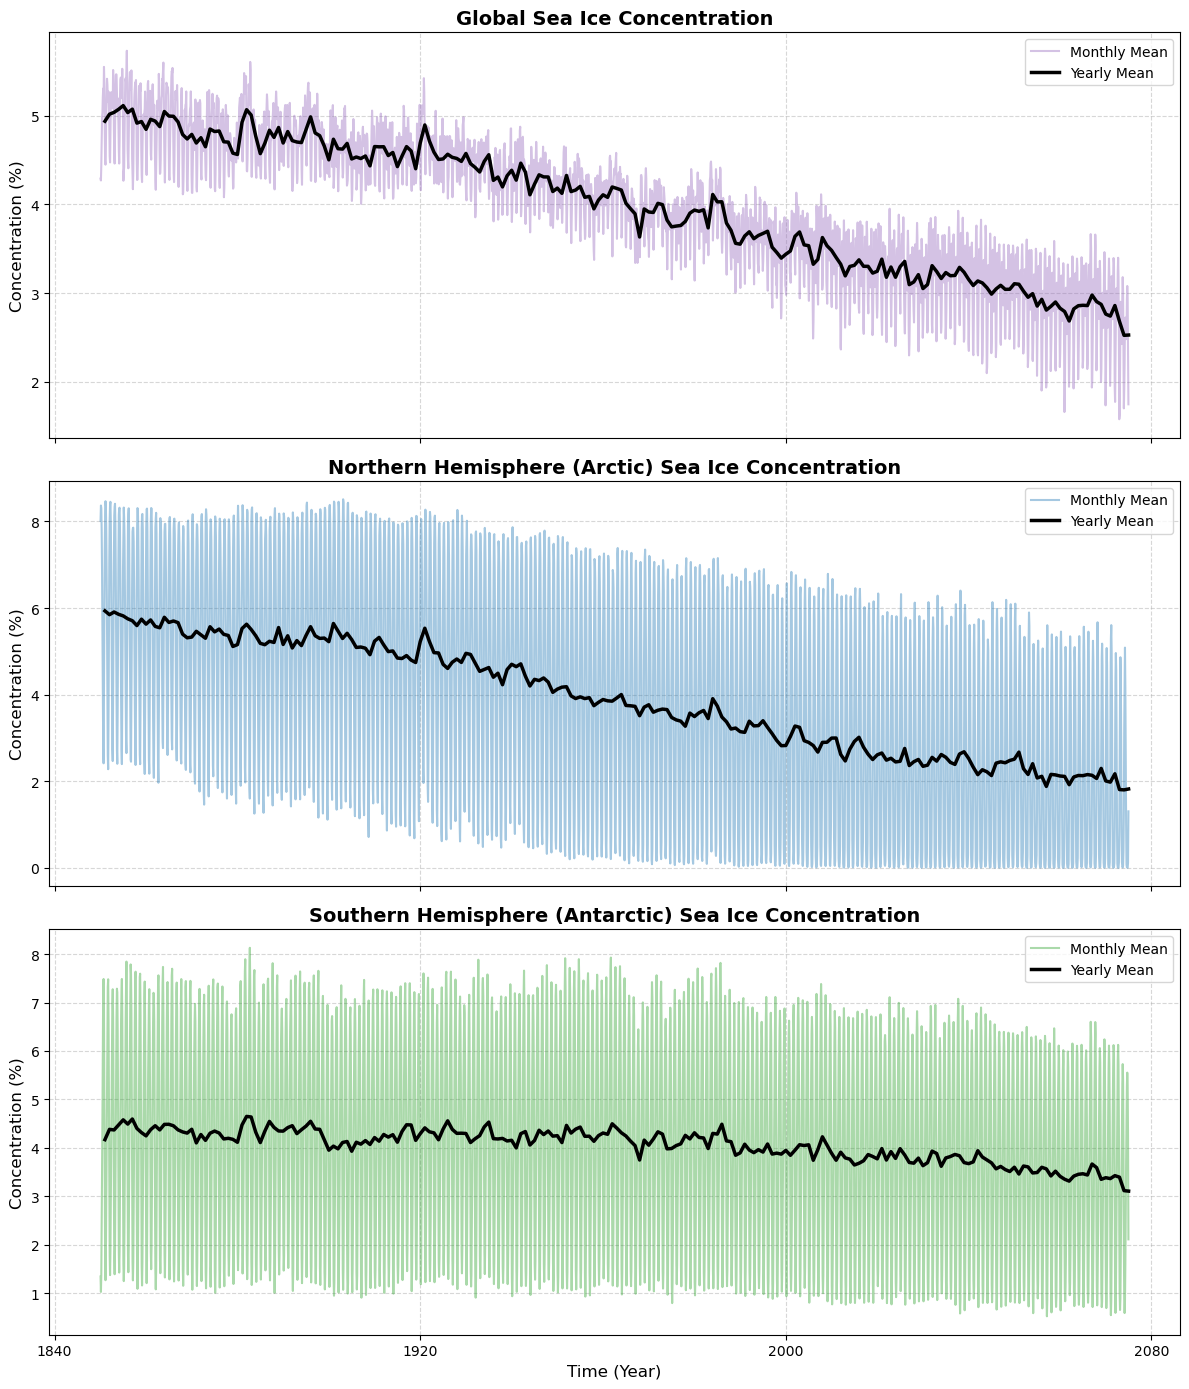

In [20]:
import xarray as xr
import numpy as np
import matplotlib.pyplot as plt
import glob
import time
import warnings

# Ignore deprecation warnings to keep the terminal output clean
warnings.filterwarnings("ignore", category=DeprecationWarning)

# --- Start Total Timer ---
total_start_time = time.time()
print("Starting 3-Panel Sea Ice Concentration Visualization Pipeline...")

# 1. Load the Data
step_start = time.time()
data_dir = "/nird/datalake/NS2980K/projects/TipESM/cmor/esm-up2p0/v20251010"
file_pattern = f"{data_dir}/siconc_SImon_NorESM2-LM_esm-up2p0_r1i1p1f1_gn_*.nc"
files = sorted(glob.glob(file_pattern))

print(f"[Step 1] Found {len(files)} siconc files. Loading via open_mfdataset...")
ds = xr.open_mfdataset(files, combine='by_coords', use_cftime=True)
step_end = time.time()
print(f"  -> Files loaded. (Time elapsed: {step_end - step_start:.2f} sec)")

# 2. Setup Area Weights (Global, NH, SH)
step_start = time.time()
lat_var = 'latitude' if 'latitude' in ds.coords else 'lat'

# Global weights with .fillna(0) to fix the NaN ValueError over land masses
weights_global = np.cos(np.deg2rad(ds[lat_var])).fillna(0)

# Hemispheric weights (also apply fillna for safety)
weights_nh = xr.where(ds[lat_var] > 0, weights_global, 0).fillna(0)
weights_sh = xr.where(ds[lat_var] < 0, weights_global, 0).fillna(0)
step_end = time.time()
print(f"[Step 2] Weights (Global, NH, SH) created. (Time elapsed: {step_end - step_start:.2f} sec)")

# 3. Compute Weighted Means (Monthly and Yearly)
step_start = time.time()
print("[Step 3] Computing Global, NH, and SH means (This may take a moment)...")
siconc = ds['siconc']

# Compute Global Data
siconc_global_monthly = siconc.weighted(weights_global).mean(dim=['j', 'i']).compute()
siconc_global_yearly = siconc.weighted(weights_global).mean(dim=['j', 'i']).resample(time='Y').mean().compute()

# Compute NH Data
siconc_nh_monthly = siconc.weighted(weights_nh).mean(dim=['j', 'i']).compute()
siconc_nh_yearly = siconc.weighted(weights_nh).mean(dim=['j', 'i']).resample(time='Y').mean().compute()

# Compute SH Data
siconc_sh_monthly = siconc.weighted(weights_sh).mean(dim=['j', 'i']).compute()
siconc_sh_yearly = siconc.weighted(weights_sh).mean(dim=['j', 'i']).resample(time='Y').mean().compute()

step_end = time.time()
print(f"[Step 3] Data computation finished. (Time elapsed: {step_end - step_start:.2f} sec)")

# 4. Visualization (3-Panel Layout)
step_start = time.time()
print("[Step 4] Rendering plots...")

# Create 3 subplots vertically
fig, axes = plt.subplots(3, 1, figsize=(12, 14), sharex=True)

# --- Plot 1: Global ---
siconc_global_monthly.plot(ax=axes[0], color='#9467bd', linewidth=1.5, alpha=0.4, label='Monthly Mean')
siconc_global_yearly.plot(ax=axes[0], color='black', linewidth=2.5, label='Yearly Mean')

axes[0].set_title('Global Sea Ice Concentration', fontsize=14, fontweight='bold')
axes[0].set_ylabel('Concentration (%)', fontsize=12)
axes[0].set_xlabel('')
axes[0].grid(True, linestyle='--', alpha=0.5)
axes[0].legend(loc='upper right')

# --- Plot 2: Northern Hemisphere (Arctic) ---
siconc_nh_monthly.plot(ax=axes[1], color='#1f77b4', linewidth=1.5, alpha=0.4, label='Monthly Mean')
siconc_nh_yearly.plot(ax=axes[1], color='black', linewidth=2.5, label='Yearly Mean')

axes[1].set_title('Northern Hemisphere (Arctic) Sea Ice Concentration', fontsize=14, fontweight='bold')
axes[1].set_ylabel('Concentration (%)', fontsize=12)
axes[1].set_xlabel('')
axes[1].grid(True, linestyle='--', alpha=0.5)
axes[1].legend(loc='upper right')

# --- Plot 3: Southern Hemisphere (Antarctic) ---
siconc_sh_monthly.plot(ax=axes[2], color='#2ca02c', linewidth=1.5, alpha=0.4, label='Monthly Mean')
siconc_sh_yearly.plot(ax=axes[2], color='black', linewidth=2.5, label='Yearly Mean')

axes[2].set_title('Southern Hemisphere (Antarctic) Sea Ice Concentration', fontsize=14, fontweight='bold')
axes[2].set_ylabel('Concentration (%)', fontsize=12)
axes[2].set_xlabel('Time (Year)', fontsize=12)
axes[2].grid(True, linestyle='--', alpha=0.5)
axes[2].legend(loc='upper right')

plt.tight_layout()

step_end = time.time()
print(f"[Step 4] Plotting finished. (Time elapsed: {step_end - step_start:.2f} sec)")

# --- End Total Timer ---
total_end_time = time.time()
print("-" * 50)
print(f"Total visualization execution time: {total_end_time - total_start_time:.2f} seconds")

# plt.savefig('global_nh_sh_siconc_timeseries.png', dpi=300, bbox_inches='tight')
plt.show()

Starting Spatial Analysis Pipeline with mlotst-based Land Masking...
[Step 1] Loading 'o2_inv_mld' and 'mlotst' via open_mfdataset...
  -> Data loaded. (Time elapsed: 0.69 sec)
[Step 2] Computing yearly means and global average...
  -> Global means prepared. (Time elapsed: 0.26 sec)
[Step 3] Calculating statistics...
  -> Statistics calculated. (Time elapsed: 5.34 sec)
[Step 4] Regridding to 1x1 grid...
  -> Regridding and masking complete. (Time elapsed: 3.76 sec)
[Step 5] Rendering plots...


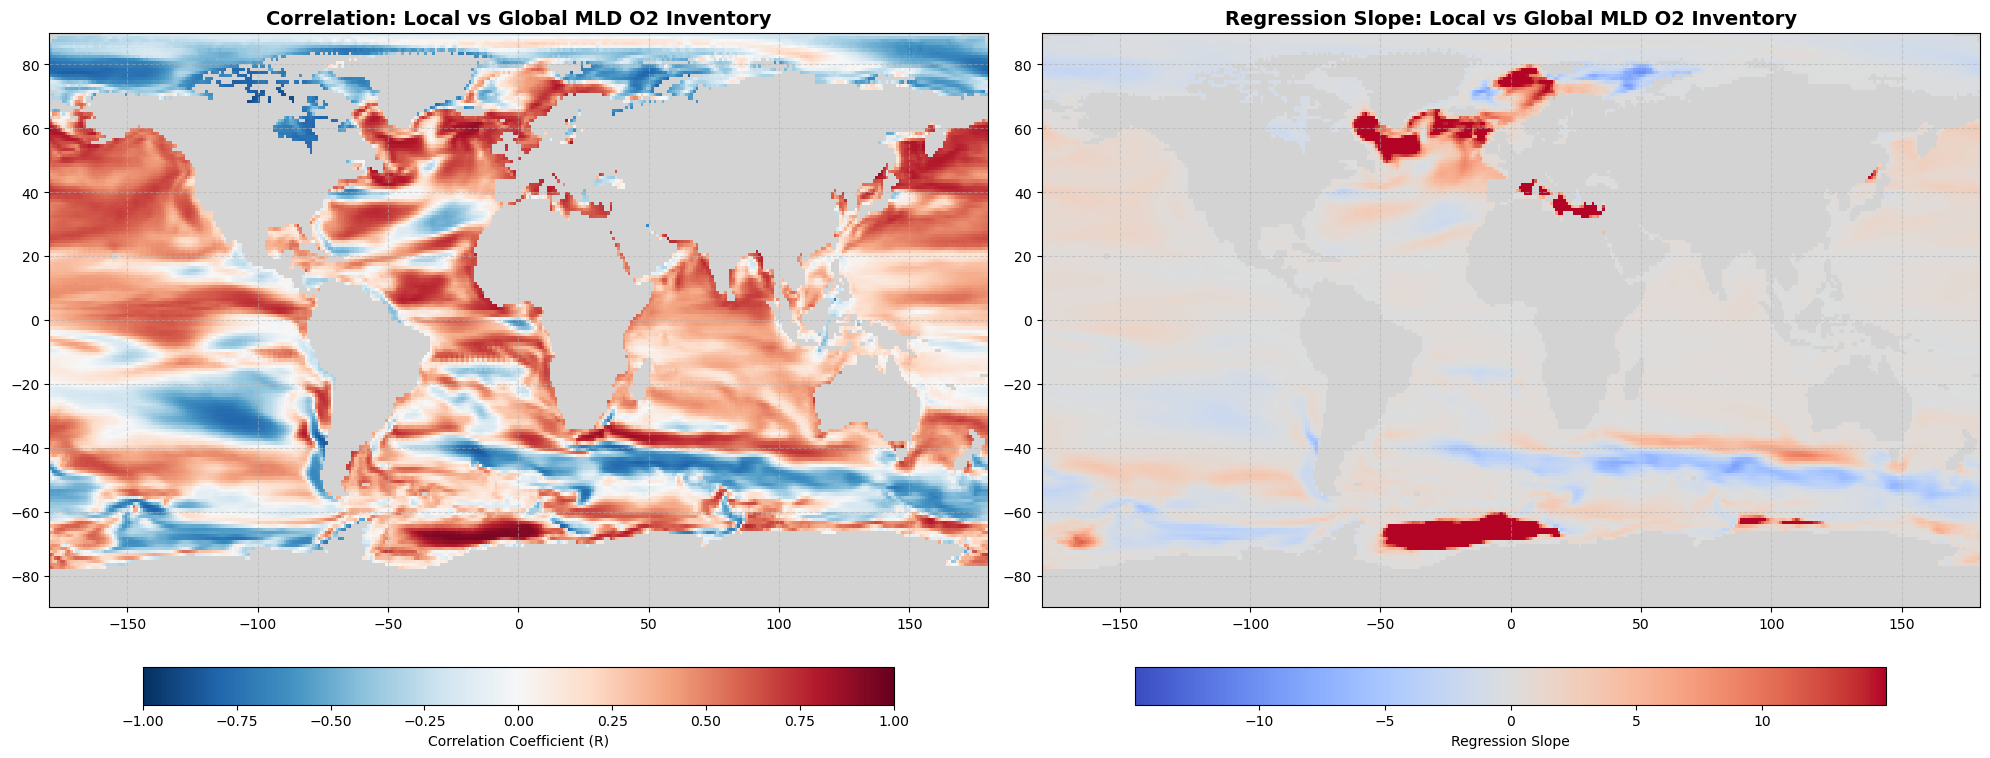

Total pipeline execution time: 10.58 seconds


In [3]:
import xarray as xr
import numpy as np
import matplotlib.pyplot as plt
from scipy.interpolate import griddata
import glob
import time
import warnings

# Ignore warnings
warnings.filterwarnings("ignore")

# --- Start Total Timer ---
total_start_time = time.time()
print("Starting Spatial Analysis Pipeline with mlotst-based Land Masking...")

# 1. Load Data
step_start = time.time()
data_dir = "/nird/datalake/NS2980K/users/yongyub/O2_linearlity/TipESM/cmor/esm-up2p0/v20251010/o2-inventories"
file_pattern = f"{data_dir}/o2-inventories_Omon_NorESM2-LM_esm-up2p0_r1i1p1f1_gr_*.nc"
files = sorted(glob.glob(file_pattern))

print(f"[Step 1] Loading 'o2_inv_mld' and 'mlotst' via open_mfdataset...")
ds = xr.open_mfdataset(files, combine='by_coords', use_cftime=True)[['o2_inv_mld', 'mlotst']]

lat_var = 'latitude' if 'latitude' in ds.coords else 'lat'
lon_var = 'longitude' if 'longitude' in ds.coords else 'lon'
step_end = time.time()
print(f"  -> Data loaded. (Time elapsed: {step_end - step_start:.2f} sec)")

# 2. Resample & Compute Global Mean
step_start = time.time()
print("[Step 2] Computing yearly means and global average...")
da_local = ds['o2_inv_mld'].resample(time='Y').mean()

# Define land mask based on the first timestep of mlotst
land_mask_raw = ds['mlotst'].isel(time=0).isnull().values

weights = np.cos(np.deg2rad(ds[lat_var])).fillna(0)
da_global = da_local.weighted(weights).mean(dim=['j', 'i'])
step_end = time.time()
print(f"  -> Global means prepared. (Time elapsed: {step_end - step_start:.2f} sec)")

# 3. Calculate Correlation and Regression
step_start = time.time()
print("[Step 3] Calculating statistics...")
r_map = xr.corr(da_local, da_global, dim='time')
cov_map = xr.cov(da_local, da_global, dim='time')
var_global = da_global.var(dim='time')
slope_map = cov_map / var_global

r_map_raw = r_map.compute()
slope_map_raw = slope_map.compute()
step_end = time.time()
print(f"  -> Statistics calculated. (Time elapsed: {step_end - step_start:.2f} sec)")

# 4. Regridding to 1x1 grid with Land Masking
step_start = time.time()
print("[Step 4] Regridding to 1x1 grid...")

lon_target = np.arange(-179.5, 180.5, 1.0)
lat_target = np.arange(-89.5, 90.5, 1.0)
lon_mesh, lat_mesh = np.meshgrid(lon_target, lat_target)

lon_src = ds[lon_var].values.flatten()
lat_src = ds[lat_var].values.flatten()
lon_src = np.where(lon_src > 180, lon_src - 360, lon_src)

valid_mask = ~np.isnan(r_map_raw.values.flatten())

# Interpolate Data
r_regridded = griddata((lon_src[valid_mask], lat_src[valid_mask]), r_map_raw.values.flatten()[valid_mask], (lon_mesh, lat_mesh), method='linear')
slope_regridded = griddata((lon_src[valid_mask], lat_src[valid_mask]), slope_map_raw.values.flatten()[valid_mask], (lon_mesh, lat_mesh), method='linear')

# Interpolate Land Mask
land_mask_1x1 = griddata((lon_src, lat_src), land_mask_raw.flatten(), (lon_mesh, lat_mesh), method='nearest').astype(bool)

# Apply Mask
r_regridded[land_mask_1x1] = np.nan
slope_regridded[land_mask_1x1] = np.nan

step_end = time.time()
print(f"  -> Regridding and masking complete. (Time elapsed: {step_end - step_start:.2f} sec)")

# 5. Visualization
step_start = time.time()
print("[Step 5] Rendering plots...")

fig, axes = plt.subplots(1, 2, figsize=(20, 8))

cmap_r = plt.get_cmap('RdBu_r').copy()
cmap_r.set_bad(color='lightgray')

cmap_s = plt.get_cmap('coolwarm').copy()
cmap_s.set_bad(color='lightgray')

# Plot Correlation
c1 = axes[0].pcolormesh(lon_target, lat_target, r_regridded, cmap=cmap_r, vmin=-1, vmax=1)
plt.colorbar(c1, ax=axes[0], label='Correlation Coefficient (R)', shrink=0.8, orientation='horizontal', pad=0.08)
axes[0].set_title('Correlation: Local vs Global MLD O2 Inventory', fontsize=14, fontweight='bold')
axes[0].grid(True, linestyle='--', alpha=0.5)

# Plot Slope
valid = slope_regridded[~np.isnan(slope_regridded)]

# Robust symmetric color limits (using 98th percentile of absolute values)
absmax = np.percentile(np.abs(valid), 98)

c2 = axes[1].pcolormesh(
    lon_target,
    lat_target,
    slope_regridded,
    cmap=cmap_s,
    vmin=-absmax,
    vmax= absmax,
)

plt.colorbar(
    c2,
    ax=axes[1],
    label='Regression Slope',
    shrink=0.8,
    orientation='horizontal',
    pad=0.08
)

axes[1].set_title(
    'Regression Slope: Local vs Global MLD O2 Inventory',
    fontsize=14,
    fontweight='bold'
)
axes[1].grid(True, linestyle='--', alpha=0.5)

plt.tight_layout()
plt.show()
print(f"Total pipeline execution time: {time.time() - total_start_time:.2f} seconds")

In [4]:
import xarray as xr
import glob
import os
import warnings

# Ignore warnings to keep the output clean
warnings.filterwarnings("ignore")

print("Starting variable extraction pipeline...")

# 1. Set the directory path
directory = "/nird/datalake/NS2980K/projects/TipESM/cmor/esm-up2p0/v20251010/"
# Search for the files from the 185001-185912 period to get one file per variable
file_pattern = os.path.join(directory, "*_185001-185912.nc")
files = sorted(glob.glob(file_pattern))

print(f"Found {len(files)} files. Extracting metadata...\n")

# 2. Print the header for the table
print(f"{'Short Name':<15} | {'Long Name (Description)'}")
print("-" * 80)

# 3. Loop through each file and extract the variable details
for file_path in files:
    filename = os.path.basename(file_path)
    
    # Extract the short variable name from the CMIP6 file naming convention
    short_name = filename.split('_')[0]
    
    try:
        # Open the dataset without decoding time (much faster for metadata extraction)
        ds = xr.open_dataset(file_path, decode_times=False)
        
        # Check if the short name exists in the dataset variables
        if short_name in ds.variables:
            # Extract the 'long_name' attribute, provide a default if missing
            long_name = ds[short_name].attrs.get('long_name', 'Description not found in metadata')
        else:
            long_name = "Variable missing in file"
            
        # Print the formatted output
        print(f"{short_name:<15} | {long_name}")
        
        # Close the dataset to free up memory
        ds.close()
        
    except Exception as e:
        print(f"{short_name:<15} | [Error reading file]")

print("\nExtraction complete.")

Starting variable extraction pipeline...
Found 313 files. Extracting metadata...

Short Name      | Long Name (Description)
--------------------------------------------------------------------------------
agessc          | Sea Water Age Since Surface Contact
agessc          | Sea Water Age Since Surface Contact
bfe             | Mole Concentration of Particulate Organic Matter Expressed as Iron in Sea Water
bfeos           | Surface Mole Concentration of Particulate Organic Matter Expressed as Iron in Sea Water
bldep           | Boundary Layer Depth
bsi             | Mole Concentration of Particulate Organic Matter Expressed as Silicon in Sea Water
bsios           | Surface Mole Concentration of Particulate Organic Matter Expressed as Silicon in Sea Water
calc            | Calcite Concentration
calcos          | Surface Calcite Concentration
ccn             | Cloud Condensation Nuclei Concentration at Liquid Cloud Top
cdnc            | Cloud Liquid Droplet Number Concentration
cfc11glo

In [5]:
import xarray as xr
import glob
import os
import warnings

# Ignore warnings to keep the output clean
warnings.filterwarnings("ignore")

print("Starting Omon variable extraction pipeline...")

# 1. Set the directory path
directory = "/nird/datalake/NS2980K/projects/TipESM/cmor/esm-up2p0/v20251010/"

# Explicitly filter for files containing '_Omon_' to ensure only Ocean Monthly data is processed
file_pattern = os.path.join(directory, "*_Omon_*_185001-185912.nc")
files = sorted(glob.glob(file_pattern))

print(f"Found {len(files)} 'Omon' files. Extracting metadata...\n")

# 2. Print the header for the table
print(f"{'Short Name':<15} | {'Long Name (Description)'}")
print("-" * 80)

# 3. Loop through each filtered file and extract the variable details
for file_path in files:
    filename = os.path.basename(file_path)
    
    # Extract the short variable name from the CMIP6 file naming convention
    short_name = filename.split('_')[0]
    
    try:
        # Open the dataset without decoding time (much faster for metadata extraction)
        ds = xr.open_dataset(file_path, decode_times=False)
        
        # Check if the short name exists in the dataset variables
        if short_name in ds.variables:
            # Extract the 'long_name' attribute, provide a default if missing
            long_name = ds[short_name].attrs.get('long_name', 'Description not found in metadata')
        else:
            long_name = "Variable missing in file"
            
        # Print the formatted output
        print(f"{short_name:<15} | {long_name}")
        
        # Close the dataset to free up memory
        ds.close()
        
    except Exception as e:
        print(f"{short_name:<15} | [Error reading file]")

print("\nExtraction complete.")

Starting Omon variable extraction pipeline...
Found 138 'Omon' files. Extracting metadata...

Short Name      | Long Name (Description)
--------------------------------------------------------------------------------
agessc          | Sea Water Age Since Surface Contact
agessc          | Sea Water Age Since Surface Contact
bfe             | Mole Concentration of Particulate Organic Matter Expressed as Iron in Sea Water
bfeos           | Surface Mole Concentration of Particulate Organic Matter Expressed as Iron in Sea Water
bsi             | Mole Concentration of Particulate Organic Matter Expressed as Silicon in Sea Water
bsios           | Surface Mole Concentration of Particulate Organic Matter Expressed as Silicon in Sea Water
calc            | Calcite Concentration
calcos          | Surface Calcite Concentration
chl             | Mass Concentration of Total Phytoplankton Expressed as Chlorophyll in Sea Water
chlos           | Surface Mass Concentration of Total Phytoplankton Express

In [17]:
import xarray as xr
import glob
import os
import warnings

# Ignore warnings to keep the output clean
warnings.filterwarnings("ignore")

print("Starting Omon variable extraction pipeline...")

# 1. Set the directory path
directory = "/nird/datalake/NS2980K/projects/TipESM/cmor/esm-up2p0/v20251010/"

# Explicitly filter for files containing '_Omon_' to ensure only Ocean Monthly data is processed
file_pattern = os.path.join(directory, "*_SImon_*_185001-185912.nc")
files = sorted(glob.glob(file_pattern))

print(f"Found {len(files)} 'Omon' files. Extracting metadata...\n")

# 2. Print the header for the table
print(f"{'Short Name':<15} | {'Long Name (Description)'}")
print("-" * 80)

# 3. Loop through each filtered file and extract the variable details
for file_path in files:
    filename = os.path.basename(file_path)
    
    # Extract the short variable name from the CMIP6 file naming convention
    short_name = filename.split('_')[0]
    
    try:
        # Open the dataset without decoding time (much faster for metadata extraction)
        ds = xr.open_dataset(file_path, decode_times=False)
        
        # Check if the short name exists in the dataset variables
        if short_name in ds.variables:
            # Extract the 'long_name' attribute, provide a default if missing
            long_name = ds[short_name].attrs.get('long_name', 'Description not found in metadata')
        else:
            long_name = "Variable missing in file"
            
        # Print the formatted output
        print(f"{short_name:<15} | {long_name}")
        
        # Close the dataset to free up memory
        ds.close()
        
    except Exception as e:
        print(f"{short_name:<15} | [Error reading file]")

print("\nExtraction complete.")

Starting Omon variable extraction pipeline...
Found 73 'Omon' files. Extracting metadata...

Short Name      | Long Name (Description)
--------------------------------------------------------------------------------
sfdsi           | Downward Sea Ice Basal Salt Flux
siage           | Age of Sea Ice
siarean         | Sea-Ice Area North
siareas         | Sea-Ice Area South
sicompstren     | Compressive Sea Ice Strength
siconc          | Sea-Ice Area Percentage (Ocean Grid)
sidconcdyn      | Sea-Ice Area Percentage Tendency Due to Dynamics
sidconcth       | Sea-Ice Area Percentage Tendency Due to Thermodynamics
sidivvel        | Divergence of the Sea-Ice Velocity Field
sidmassdyn      | Sea-Ice Mass Change from Dynamics
sidmassevapsubl | Sea-Ice Mass Change Through Evaporation and Sublimation
sidmassgrowthbot | Sea-Ice Mass Change Through Basal Growth
sidmassgrowthwat | Sea-Ice Mass Change Through Growth in Supercooled Open Water (Frazil)
sidmasslat      | Lateral Sea Ice Melt Rate
sidmas